In [ ]:
!pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## slurm

In [4]:
run_ids = ['1_1', '1_2', '2_1_1', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']

In [5]:
# ld=16 sbatch commands
for run_id in run_ids:
    print(f'sbatch vertex_{run_id}_16.slrm')

sbatch vertex_1_1_16.slrm
sbatch vertex_1_2_16.slrm
sbatch vertex_2_1_1_16.slrm
sbatch vertex_2_1_2_16.slrm
sbatch vertex_2_2_1_16.slrm
sbatch vertex_2_2_2_16.slrm
sbatch vertex_2_3_1_16.slrm
sbatch vertex_2_3_2_16.slrm
sbatch vertex_3_1_16.slrm
sbatch vertex_3_2_16.slrm
sbatch vertex_3_3_16.slrm


In [6]:
# ld=8 sbatch commands
for run_id in run_ids:
    print(f'sbatch vertex_{run_id}_8.slrm')

sbatch vertex_1_1_8.slrm
sbatch vertex_1_2_8.slrm
sbatch vertex_2_1_1_8.slrm
sbatch vertex_2_1_2_8.slrm
sbatch vertex_2_2_1_8.slrm
sbatch vertex_2_2_2_8.slrm
sbatch vertex_2_3_1_8.slrm
sbatch vertex_2_3_2_8.slrm
sbatch vertex_3_1_8.slrm
sbatch vertex_3_2_8.slrm
sbatch vertex_3_3_8.slrm


In [ ]:
# watch jobs
squeue -u shepp123

In [5]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'

def create_slurm(version: str, contrastive: bool = False, hidden_dims: list[int] = [128, 64, 32], epochs: int = -1,
                 sample_count_per_vertex: int = -1, subset: float|int|None = None, subset_type: list[str]|str|None = None,
                 batch_size: int = -1, qos: str = 'zen3_0512_a100x2', time: str = '24:00:00'):
    model_wrapper = 'VertexWrapper24x6InfoNCE' if contrastive else 'VertexWrapper24x6'
    model_name = 'ContrastiveAutoEncoder' if contrastive else 'AutoEncoderVertex'
    dataset = 'AutoEncoder24x6InfoNCEDataset' if contrastive else 'AutoEncoderVertex24x6Dataset'
    if epochs == -1:
        epochs = 50_000 if contrastive else 25_000
    if sample_count_per_vertex == -1:
        sample_count_per_vertex = 6000 if contrastive else 24_000
    if batch_size == -1:
        batch_size = 2048 if contrastive else 8192
    trainer_kwargs = {
        'config_name': 'confmod_auto_encoder.json', 
        'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
        'config_kwargs': {
            'path_train': base_dir + 'frgs_6d',
            'resume': 'run_results/' + version,
            'model_wrapper': model_wrapper,
            'model_name': model_name,
            'dataset': dataset,
            'hidden_dims': hidden_dims,
            'epochs': epochs,
            'sample_count_per_vertex': sample_count_per_vertex, 
            'test_ratio': 0.2, 
            'subset': subset, 
            'subset_type': subset_type,
            'subset_shuffle': False, 
            'devices': 'auto', 
            'device_type': 'gpu', 
            'num_dataloader_workers': 2, 
            'batch_size': batch_size,
        }
    }
    slurm_options = slurm_generate.SlurmOptions(qos=qos, time=time)
    slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'PhysML/.venv', 
                    'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}
    slurm_generate.create(script_name='vertex_' + version, **slurm_kwargs)


def create_all_scripts(ld: int, hidden_dims: list[int]):
    create_slurm(version=f'1_1_{ld}', hidden_dims=hidden_dims)
    create_slurm(version=f'1_2_{ld}', contrastive=True, hidden_dims=hidden_dims)
    create_slurm(version=f'2_1_1_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type=['afm', 'fm'])
    create_slurm(version=f'2_1_2_{ld}', contrastive=True, hidden_dims=hidden_dims, subset=0.8, subset_type=['afm', 'fm'])
    create_slurm(version=f'2_2_1_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type=['sc', 'fm'])
    create_slurm(version=f'2_2_2_{ld}', contrastive=True, hidden_dims=hidden_dims, subset=0.8, subset_type=['sc', 'fm'])
    create_slurm(version=f'2_3_1_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type=['afm', 'sc'])
    create_slurm(version=f'2_3_2_{ld}', contrastive=True, hidden_dims=hidden_dims, subset=0.8, subset_type=['afm', 'sc'])
    create_slurm(version=f'3_1_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type='sc')
    create_slurm(version=f'3_2_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type='afm')
    create_slurm(version=f'3_3_{ld}', hidden_dims=hidden_dims, subset=0.8, subset_type='fm')

In [6]:
ld = 16
hidden_dims = [128, 64, 32, 16]
create_all_scripts(ld, hidden_dims)

In [7]:
ld = 8
hidden_dims = [128, 64, 32, 8]
create_all_scripts(ld, hidden_dims)

## setup

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)

# autoencoder
seed = 42
hidden_dims = [128, 64, 32]
train_samples_per_vertex = 24000
nce_train_samples = train_samples_per_vertex // 4
test_samples_per_vertex = 2000
config_kwargs = {
    'hidden_dims': hidden_dims,
    'epochs': 1000,
    'test_ratio': 0.2, 
    'devices': 'auto', 
    'num_dataloader_workers': 16, 
    'strategy': 'auto', 
    'batch_size': 8192 * 2,
}
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

# phase classifier
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

In [ ]:
# general train sets
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
nce_train_dataset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
nce_train_dataset_subset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, subset=0.8, 
                                                 dataset_class=AutoEncoder24x6InfoNCEDataset)

# reconstruction filepaths
ex_sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'fm'], file_paths=file_paths)[0]
ex_sc_fps = list(set(file_paths) - set(ex_sc_fps))
ex_afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                        subset_seed=seed, subset_type=['sc', 'fm'], file_paths=file_paths)[0]
ex_afm_fps = list(set(file_paths) - set(ex_afm_fps))
ex_fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'sc'], file_paths=file_paths)[0]
ex_fm_fps = list(set(file_paths) - set(ex_fm_fps))
sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='sc', file_paths=file_paths)[0]
sc_fps = list(set(file_paths) - set(sc_fps))
afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                     subset_seed=seed, subset_type='afm', file_paths=file_paths)[0]
afm_fps = list(set(file_paths) - set(afm_fps))
fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='fm', file_paths=file_paths)[0]
fm_fps = list(set(file_paths) - set(fm_fps))

# test sets
test_dataset_full = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset_subset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset_subset)


# evaluate models

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'

run_info = {
    # '1_1': (file_paths, nce_train_dataset, test_dataset_full), 
    # '1_2': (file_paths, nce_train_dataset, test_dataset_full), 
    '2_1_1': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_1_2': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_2_1': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_2_2': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_3_1': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_3_2': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_1': (sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_2': (afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_3': (fm_fps, nce_train_dataset_subset, test_dataset_subset),
}

reconstruction_results = []
classification_results = []
latent_dims = [32, 16, 8]
total = len(run_info) * len(latent_dims)
with tqdm(total=total, desc='Evaluation') as prog:
    for run_id, (recon_files, train_data, test_data) in run_info.items():
        for ld in latent_dims:
            run_name = f'{run_id}_{ld}'
            prog.set_description(f'Evaluating {run_name}')
            save_path = base_path + run_name
            rmses = verteval.mean_rmse(file_paths, vertices, save_path)
            reconstruction_results.extend([
                {'run_id': run_id, 'ld': ld, 'tp': tp, 'rmse': rmse} for tp, rmse in rmses.items()
            ])
            pc = PhaseClassification(save_path, pc_models, run_name)
            pc.train(nce_train_dataset)
            model_scores = pc.evaluate_classifiers(test_dataset_full, print_conf_mat=False)
            classification_results.append({'run_id': run_id, 'ld': ld, 'f1': list(model_scores.values())[0][0]['f1']})
            prog.update()

rmse_df = pd.DataFrame(reconstruction_results)
rmse_df.to_csv(base_path + 'reconstruction_results_ld.csv', index=False)
classification_df = pd.DataFrame(classification_results)
classification_df.to_csv(base_path + 'classification_results_ld.csv', index=False)

# show results

In [6]:
base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'

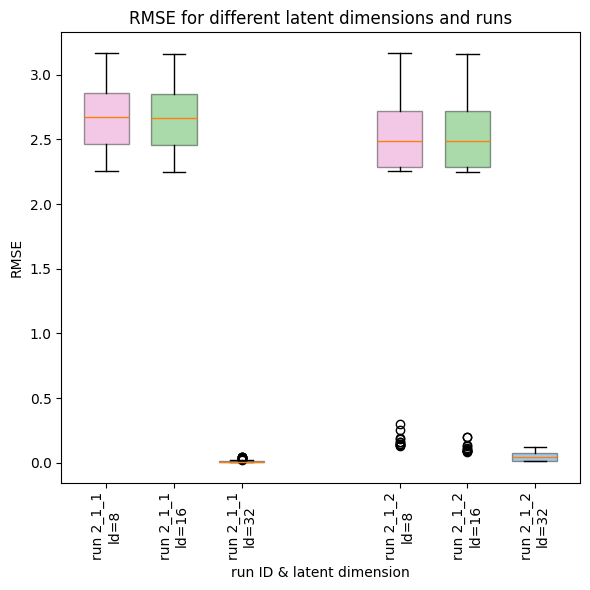

tp      rmse
run_id ld                
2_1_1  8   0.25  2.683142
       16  0.25  2.675942
       32  0.25  0.013185
2_1_2  8   0.25  2.069679
       16  0.25  2.055018
       32  0.25  0.050142

In [35]:
rmse_df = pd.read_csv(base_path + 'reconstruction_results_ld.csv')
verteval.plot_all_rmses(rmse_df, 'ld', figsize=(6, 6))

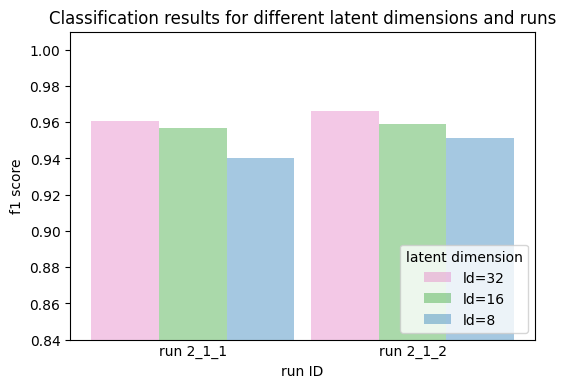

f1
run_id ld          
2_1_1  32  0.960729
       16  0.957021
       8   0.940110
2_1_2  32  0.966148
       16  0.959179
       8   0.951040

In [36]:
classification_df = pd.read_csv(base_path + 'classification_results_ld.csv')
verteval.plot_classification_results(classification_df, 'ld')